<div style="
    background-color: #7BAFD4;
    border-radius: 18px;
    padding: 22px 26px;
    display: flex;
    align-items: center;
    gap: 24px;
    margin-bottom: 18px;
">
    <img src="../592_avatar_lr.png" alt="GEOG 592"
        style="width:110px;height:110px;border-radius:22px;">
    <div>
        <div style="
            font-family: Impact, 'Arial Black', Arial, sans-serif;
            font-size: 42px;
            font-weight: 900;
            letter-spacing: 2px;
            line-height: 1;
            color: white;
        ">GEOG 592</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 22px;
            font-weight: 700;
            color: #13294B;
            margin-top: 8px;
        ">GIS Programming</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 16px;
            color: #13294B;
            margin-top: 6px;
        ">Week 07 Homework</div>
    </div>
</div>

## Deadlines: 
Monday - select data and write README file \
Wednesday - make three layers \
Friday - spatial and tabular joins

## Assignment:
Explore GeoPandas and create three new spatial layers using geoprocessing techniques. Each new layer must:

- Use two different input layers
- Use a different geoprocessing method
- Build on a different spatial question or on the results of a previous analysis
 

For example, you could create a layer of hospitals that are within a county. You could not then create a second layer of roads that intersect that same county, because the two analyses are too similar. However, you could create buffers around the hospitals selected in the first analysis and then identify roads that intersect those buffers. In this case, the second analysis builds on the results of the first.

You must also create:

One new layer using a table/attribute join. For example, you could join county polygons to a table containing census data. The resulting layer would contain both the county geometries and the census attributes.
 

One analysis using a spatial join that produces a meaningful tabular result. For example, you could spatially join hospitals to counties and then aggregate the results by county to determine the number of hospitals in each county.
 

You may not use hospitals or census data for this assignment. Those are examples only.

Try to make your analyses and maps relate to a topic that interests you. Be creative in your choice of data and spatial questions. AI use is allowed, but you should be able to explain the code and analysis you submit.

Organize all of your work in a Jupyter Notebook under week08/

Your notebook should clearly show your data sources, the methods you used, the resulting layers, and maps of your results. For the spatial analysis section you need to produce a bar graph or some kind of graph that shows the results of your analysis.

By Monday at 1pm you should have selected data for your analysis.

This can be placed in homework/week07/data

Place the link to a readme file that has an explanation about the data contained in the data/ folder, and the original source of the data. 

By Wednesday at 1pm you should already have made the three new layers. 

Provide the link to your JupyterNotebook. 

By Friday at 1pm you must have finished the spatial and tabular joins. 

Provide the link to your JupyterNotebook. The JN needs to include figures and a narrative explaining the question you are answering by applying the geospatial techniques. 

In [238]:
import geopandas as gpd
import pandas as pd 
import matplotlib.pyplot as plt

## Analysis 1: Large scale solar 
### Question: Are there any solar farms not close to interconnection lines?

Utility scale solar farms need to connect to transmission lines in order to deliver energy to users. If a solar farm is not near an existing transmission line, a new tie-in will have to be built, which is expensive. Therefore, I want to see if large scale solar sites in North Carolina are near transmission lines. \
Source: https://www.solarlandlease.com/solar-farm-connect-grid 

In [239]:
# Loading in the polygon data as a gpd 
solar_polygons = gpd.read_file("data/large_scale_solar/solar_facility_polygons.geojson", columns=["case_id", "geometry"])

# Loading in the attribute data as a pd
solar_attributes = pd.read_csv("data/large_scale_solar/solar_facility_attributes.csv")

### Attribute join 
Joining the solar facility attribute data to polygon data based on "case_id" column. 

In [240]:
solar_polygons.head()

,case_id,geometry
0,400011,"MULTIPOLYGON (((-144176.097 -530367.463, -1441..."
1,407013,"MULTIPOLYGON (((1297102.883 473228.339, 129710..."
2,404351,"MULTIPOLYGON (((486372.846 -54742.838, 486385...."
3,404352,"MULTIPOLYGON (((1685015.989 476208.804, 168501..."
4,404336,"MULTIPOLYGON (((476526.316 296695.628, 476530...."


In [241]:
solar_attributes.head()

,case_id,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,p_dig_conf,...,p_axis,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore
0,400011,single,2953,OK,Canadian,35.4774,-97.6764,50723,20220621,4,...,single-axis,180.0,25.0,NaN,2.5,3.0,greenfield,non-agrivoltaic,community solar,-0.219022
1,407013,single,67406,NY,Erie,43.0168,-78.9779,77051,20250629,4,...,single-axis,180.0,52.0,NaN,4.0,5.5,greenfield,non-agrivoltaic,community solar,-0.048823
2,404351,single,64787,IL,Macoupin,39.4045,-90.0025,56943,20210905,4,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.308881
3,404352,single,64788,NY,Greene,42.3708,-74.0406,40085,20211106,4,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.000703
4,404336,single,64734,IL,Stephenson,42.3804,-89.8412,55382,20220213,4,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.288227


In [242]:
# Attribute join 
# Default is a left join, keeps geometries 
solar_facilities = solar_polygons.merge(solar_attributes, on="case_id")
solar_facilities.head()

,case_id,geometry,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,...,p_axis,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore
0,400011,"MULTIPOLYGON (((-144176.097 -530367.463, -1441...",single,2953,OK,Canadian,35.4774,-97.6764,50723,20220621,...,single-axis,180.0,25.0,NaN,2.5,3.0,greenfield,non-agrivoltaic,community solar,-0.219022
1,407013,"MULTIPOLYGON (((1297102.883 473228.339, 129710...",single,67406,NY,Erie,43.0168,-78.9779,77051,20250629,...,single-axis,180.0,52.0,NaN,4.0,5.5,greenfield,non-agrivoltaic,community solar,-0.048823
2,404351,"MULTIPOLYGON (((486372.846 -54742.838, 486385....",single,64787,IL,Macoupin,39.4045,-90.0025,56943,20210905,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.308881
3,404352,"MULTIPOLYGON (((1685015.989 476208.804, 168501...",single,64788,NY,Greene,42.3708,-74.0406,40085,20211106,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.000703
4,404336,"MULTIPOLYGON (((476526.316 296695.628, 476530....",single,64734,IL,Stephenson,42.3804,-89.8412,55382,20220213,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.288227


In [243]:
solar_facilities.columns

Index(['case_id', 'geometry', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore'],
      dtype='str')

At this point I realized that the solar_polygons dataset already contained attribute data becuase I was getting double of each column name. I didn't want to delete the work I already did, so I changed the import for solar_polygons to include only the name and the geometry. However, do not fear, I will still do an attribute join later on in my third analysis. 

### Changing the projection

In [244]:
solar_facilities.crs

<Projected CRS: ESRI:102008>
Name: North_America_Albers_Equal_Area_Conic
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [245]:
solar_facilities = solar_facilities.to_crs(epsg=6543)
solar_facilities.head()

,case_id,geometry,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,...,p_axis,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore
0,400011,"MULTIPOLYGON (((-3527564.676 1150549.469, -352...",single,2953,OK,Canadian,35.4774,-97.6764,50723,20220621,...,single-axis,180.0,25.0,NaN,2.5,3.0,greenfield,non-agrivoltaic,community solar,-0.219022
1,407013,"MULTIPOLYGON (((2005540.745 3383919.222, 20055...",single,67406,NY,Erie,43.0168,-78.9779,77051,20250629,...,single-axis,180.0,52.0,NaN,4.0,5.5,greenfield,non-agrivoltaic,community solar,-0.048823
2,404351,"MULTIPOLYGON (((-1109953.986 2232538.025, -111...",single,64787,IL,Macoupin,39.4045,-90.0025,56943,20210905,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.308881
3,404352,"MULTIPOLYGON (((3350120.914 3180326.017, 33501...",single,64788,NY,Greene,42.3708,-74.0406,40085,20211106,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.000703
4,404336,"MULTIPOLYGON (((-946084.299 3310828.383, -9461...",single,64734,IL,Stephenson,42.3804,-89.8412,55382,20220213,...,single-axis,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.288227


### Filtering data 
Filtering for just NC. Also filtering out community solar, since these projects are smaller and use lines with lower voltage than transmission lines. 

In [246]:
# Filtering for just NC
solar_facilities = solar_facilities[solar_facilities["p_state"] == "NC"]
solar_facilities.head()

,case_id,geometry,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,...,p_axis,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore
263,407366,"MULTIPOLYGON (((1616249.939 727070.92, 1616251...",multi,68601,NC,Davidson,35.7420,-80.2924,290262,20251009,...,single-axis,180.0,0.0,NaN,4.5,5.0,greenfield,non-agrivoltaic,NaN,-0.802075
311,406473,"MULTIPOLYGON (((2356426.466 1012027.551, 23564...",multi,67161,NC,Northampton,36.5361,-77.7661,1681058,20240528,...,fixed-tilt,180.0,15.0,NaN,120.0,201.0,greenfield,non-agrivoltaic,NaN,0.621402
314,400471,"MULTIPOLYGON (((1335595.878 653578.348, 133544...",multi,58332,NC,Lincoln,35.5260,-81.2351,85746,20210408,...,fixed-tilt,180.0,20.0,NaN,5.0,6.0,greenfield,non-agrivoltaic,NaN,-0.068396
315,400725,"MULTIPOLYGON (((2338720.503 617243.755, 233872...",multi,58782,NC,Wayne,35.4388,-77.8636,94069,20220917,...,fixed-tilt,180.0,20.0,NaN,5.0,7.0,greenfield,non-agrivoltaic,NaN,-0.006649
321,400464,"MULTIPOLYGON (((1354431.33 745049.187, 1354432...",multi,58315,NC,Catawba,35.7785,-81.1767,109744,20210825,...,fixed-tilt,180.0,25.0,NaN,5.0,6.5,greenfield,non-agrivoltaic,NaN,-0.217854


In [247]:
# Checking to see the term used for community solar
solar_facilities["p_comm"].unique()

<StringArray>
[nan]
Length: 1, dtype: str

There aren't any community solar facilities in NC, so the dataframe doesn't need to be filtered after all. 

In [248]:
# Changing the name to solar_farms because I keep misspelling facilities and making a copy for good measure. 
solar_farms = solar_facilities.copy()

### Buffering the polygons 
Developers aim to be two miles within a interconnection line. Source: https://biologyinsights.com/how-close-does-a-solar-farm-need-to-be-to-a-substation/ 
The projection is measured in feet, so two miles is a buffer size of 10560 feet. 

In [249]:
solar_farms['buffer'] = solar_farms.buffer(10560)
solar_farms.head()

,case_id,geometry,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,...,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore,buffer
263,407366,"MULTIPOLYGON (((1616249.939 727070.92, 1616251...",multi,68601,NC,Davidson,35.7420,-80.2924,290262,20251009,...,180.0,0.0,NaN,4.5,5.0,greenfield,non-agrivoltaic,NaN,-0.802075,"POLYGON ((1604692.111 727439.772, 1604689.75 7..."
311,406473,"MULTIPOLYGON (((2356426.466 1012027.551, 23564...",multi,67161,NC,Northampton,36.5361,-77.7661,1681058,20240528,...,180.0,15.0,NaN,120.0,201.0,greenfield,non-agrivoltaic,NaN,0.621402,"POLYGON ((2345410.832 1015252.387, 2345529.435..."
314,400471,"MULTIPOLYGON (((1335595.878 653578.348, 133544...",multi,58332,NC,Lincoln,35.5260,-81.2351,85746,20210408,...,180.0,20.0,NaN,5.0,6.0,greenfield,non-agrivoltaic,NaN,-0.068396,"POLYGON ((1336718.785 642952.023, 1336695.311 ..."
315,400725,"MULTIPOLYGON (((2338720.503 617243.755, 233872...",multi,58782,NC,Wayne,35.4388,-77.8636,94069,20220917,...,180.0,20.0,NaN,5.0,7.0,greenfield,non-agrivoltaic,NaN,-0.006649,"POLYGON ((2327724.921 614030.382, 2327596.462 ..."
321,400464,"MULTIPOLYGON (((1354431.33 745049.187, 1354432...",multi,58315,NC,Catawba,35.7785,-81.1767,109744,20210825,...,180.0,25.0,NaN,5.0,6.5,greenfield,non-agrivoltaic,NaN,-0.217854,"POLYGON ((1349838.004 755554.213, 1350055.718 ..."


<Axes: >

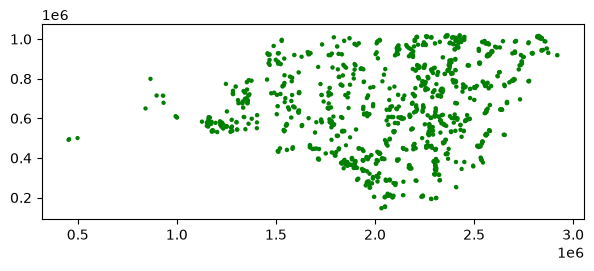

In [250]:
fig, ax = plt.subplots(figsize=(7,7))
solar_farms.plot(ax=ax, color="blue")
solar_farms["buffer"].plot(ax=ax, color="green")

Zooming into one county to look at the buffer

In [251]:
counties = solar_farms['p_county'].value_counts()
counties.head(20)

p_county
Robeson        42
Duplin         34
Wayne          32
Nash           31
Johnston       29
Cleveland      24
Scotland       18
Columbus       18
Northampton    17
Randolph       17
Hertford       16
Bladen         16
Martin         15
Cumberland     14
Catawba        13
Lenoir         13
Halifax        13
Sampson        13
Wilson         13
Vance          13
Name: count, dtype: int64

<Axes: >

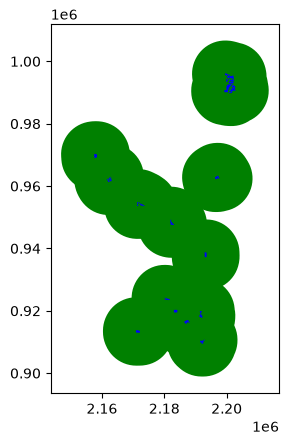

In [252]:
fig, ax = plt.subplots()
vance = solar_farms[solar_farms['p_county'] == 'Vance']
vance["buffer"].plot(ax=ax, color="green")
vance.plot(ax=ax, color="blue")

### Clipping the transmission line data 

In [253]:
# Loading in the transmission line data as a gpd
transmission_lines = gpd.read_file("data/large_scale_solar/transmission_lines.geojson")

# Loading in the North Carolina state outline polygon 
nc_counties = gpd.read_file("data/large_scale_solar/nc_counties.geojson")

In [254]:
# Changing the projections 
transmission_lines = transmission_lines.to_crs(epsg=6543)
nc_counties = nc_counties.to_crs(epsg=6543)

<Axes: >

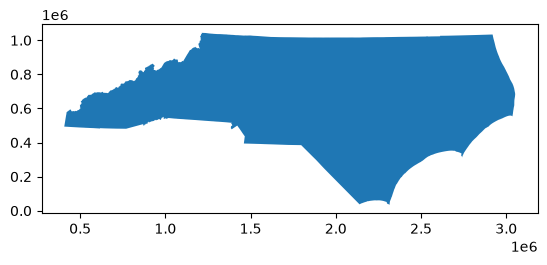

In [255]:
# Making a polygon for just the NC border by dissolving the county borders. 
nc = nc_counties.dissolve()
fig, ax = plt.subplots()
nc.plot(ax=ax)

In [256]:
nc.head()

,geometry,OBJECTID,County,FIPS,Rec_Survey,NCGS_url,ck_date,Shape__Area,Shape__Length,GlobalID
0,"POLYGON ((657245.879 482813.967, 657144.453 48...",1,Alamance,001,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.210717e+10,476733.362073,acd66e2b-e702-4b3a-82c1-eb86e12d3804


In [257]:
# Clipping the transmission line data to the NC polygon 
lines_nc = gpd.clip(transmission_lines, nc)

<Axes: >

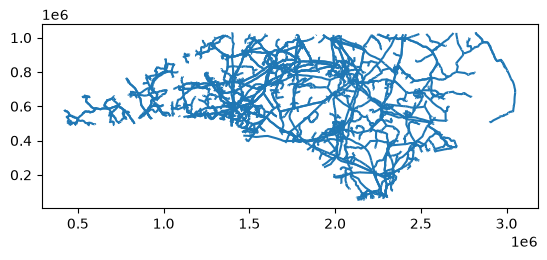

In [258]:
fig, ax = plt.subplots()
lines_nc.plot(ax=ax)

### Intersecting the polygons and the transmission lines

In [259]:
# Adds transmission line data to each polygon that it intersects. 
# If multiple, each polygon will have entries with different transmission line data. 
solar_intersect = gpd.sjoin(solar_farms, lines_nc, how='left', predicate='intersects')
solar_intersect.head()

,case_id,geometry,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,...,NAICS_CODE,NAICS_DESC,OBJECTID_1,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,INFERRED,Shape__Len,Shape__L_1
263,407366,"MULTIPOLYGON (((1616249.939 727070.92, 1616251...",multi,68601,NC,Davidson,35.7420,-80.2924,290262,20251009,...,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,5658.0,IMAGERY,2014-07-14,IMAGERY,2014-07-23,N,1627.319210,1627.319195
311,406473,"MULTIPOLYGON (((2356426.466 1012027.551, 23564...",multi,67161,NC,Northampton,36.5361,-77.7661,1681058,20240528,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
314,400471,"MULTIPOLYGON (((1335595.878 653578.348, 133544...",multi,58332,NC,Lincoln,35.5260,-81.2351,85746,20210408,...,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,11624.0,IMAGERY,2014-07-23,IMAGERY,2014-07-23,N,3637.217275,3637.217260
315,400725,"MULTIPOLYGON (((2338720.503 617243.755, 233872...",multi,58782,NC,Wayne,35.4388,-77.8636,94069,20220917,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
321,400464,"MULTIPOLYGON (((1354431.33 745049.187, 1354432...",multi,58315,NC,Catawba,35.7785,-81.1767,109744,20210825,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


### Analysis
Counting the number of transmission lines that intersect with the buffered polygons and creating a Boolean column for those that do not have a transmission line intersection 

In [260]:
solar_intersect.columns

Index(['case_id', 'geometry', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore', 'buffer', 'index_right',
       'ID', 'OWNER', 'STATUS', 'VOLTAGE', 'VOLT_CLASS', 'TYPE', 'SUB_1',
       'SUB_2', 'NAICS_CODE', 'NAICS_DESC', 'OBJECTID_1', 'SOURCE',
       'SOURCEDATE', 'VAL_METHOD', 'VAL_DATE', 'INFERRED', 'Shape__Len',
       'Shape__L_1'],
      dtype='str')

In [261]:
lines_nc.head()

,ID,OWNER,STATUS,VOLTAGE,VOLT_CLASS,TYPE,SUB_1,SUB_2,NAICS_CODE,NAICS_DESC,OBJECTID_1,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,INFERRED,Shape__Len,Shape__L_1,geometry
3255,103777,PROGRESS ENERGY CAROLINAS INC,IN SERVICE,-999999.0,100-161,OVERHEAD,UNKNOWN112224,TAP148358,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,3256,"IMAGERY, EIA 861",2014-06-17,IMAGERY,2014-07-23,Y,16.438270,16.438225,"LINESTRING (2440599.985 273654.829, 2440624.87..."
10463,112007,PROGRESS ENERGY CAROLINAS INC,IN SERVICE,-999999.0,100-161,OVERHEAD,TAP148357,TAP148358,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,10464,"IMAGERY, EIA 861",2014-06-17,IMAGERY,2014-07-23,Y,112.154826,112.154813,"LINESTRING (2440826.219 273856.376, 2440599.98..."
44025,150514,PROGRESS ENERGY CAROLINAS INC,IN SERVICE,-999999.0,100-161,OVERHEAD,UNKNOWN112223,TAP148357,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,44026,"IMAGERY, EIA 861",2014-06-17,IMAGERY,2014-07-23,Y,64.742571,64.742531,"LINESTRING (2440826.219 273856.376, 2440954.04..."
3526,104092,PROGRESS ENERGY CAROLINAS INC,IN SERVICE,-999999.0,100-161,OVERHEAD,TAP148356,TAP148357,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,3527,"IMAGERY, EIA 861",2014-06-17,IMAGERY,2014-07-23,Y,5540.152788,5540.152790,"LINESTRING (2448498.763 285750.106, 2448668.21..."
8661,109947,PROGRESS ENERGY CAROLINAS INC,IN SERVICE,-999999.0,100-161,OVERHEAD,UNKNOWN112222,TAP148356,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,8662,"IMAGERY, EIA 861",2014-06-17,IMAGERY,2014-07-23,Y,62.461606,62.461642,"LINESTRING (2448498.763 285750.106, 2448653.70..."


In [262]:
solar_counts = solar_intersect.value_counts('case_id')
solar_counts

case_id
407367    2
407366    1
406473    1
400471    1
400725    1
         ..
403324    1
402162    1
404750    1
406003    1
404079    1
Name: count, Length: 760, dtype: int64

In [263]:
solar_counts.isna().value_counts()

count
False    760
Name: count, dtype: int64

The result of my analysis is that all the solar farms have a interconnection line within two miles. In retrospect, I should have tried to find data for solar farms that are currently being built, not ones that are completed. However, this result does make sense that most farms are near an interconnection line. However, if there were any not within 2 miles, that would indicate that more transmission lines should be built. 

## Analysis 2: Smog 
### Question: What areas might be at risk for smog?

Two key ingredients of smog are ozone and particulate matter (PM). I will overlay areas that are in non-attainment for ozone and PM to see areas that might be at higher risk for smog. 

### Merging the PM2.5 and PM10 datasets
### Attempt 1

In [277]:
# Loading data in 
pm10 = gpd.read_file("data/smog_analysis/pm10.geojson")
pm25 = gpd.read_file("data/smog_analysis/pm25.geojson")

pm10 = pm10.to_crs(epsg=3857)
pm25 = pm25.to_crs(epsg=3857)

In [265]:
pm10.head()

,AREA_NAME,COMPOSID,geometry
0,"Ada County; Boise, ID",PM-10.1990.Boise,"MULTIPOLYGON (((-116.51312 43.37874, -116.5135..."
1,"Adams, Denver, and Boulder Counties; Denver Me...",PM-10.1990.Denver,"MULTIPOLYGON (((-105.3285 39.12996, -105.33048..."
2,"Allegheny County; The area including Liberty, ...",PM-10.1990.Liberty-Clairton,"MULTIPOLYGON (((-79.89967 40.31888, -79.89868 ..."
3,"Anchorage; Eagle River, AK",PM-10.1990.Anchorage,"MULTIPOLYGON (((-149.48582 61.31063, -149.5792..."
4,"Archuleta County; Pagosa Springs, CO",PM-10.1990.Pagosa_Springs,"MULTIPOLYGON (((-107.48174 37.00001, -107.4817..."


In [266]:
pm25.head()

,AREA_NAME,Status,Status_120,Id,NAME,COMPOSID,geometry
0,"Lebanon, PA",NaN,Nonattainment,0,None,PM-2.5.2012.Lebanon_Co,"MULTIPOLYGON (((-76.25124 40.37825, -76.24976 ..."
1,"Allegheny County, PA",NaN,Nonattainment,0,None,PM-2.5.2012.Allegheny_Co,"MULTIPOLYGON (((-80.1406 40.67427, -80.13695 4..."
2,"Delaware County, PA",NaN,Nonattainment,0,None,PM-2.5.2012.Delaware_Co,"MULTIPOLYGON (((-75.32099 40.01649, -75.32071 ..."
3,"Imperial County, CA",NaN,Nonattainment,0,None,PM-2.5.2012.Imperial_Co,"MULTIPOLYGON (((-115.71819 33.07505, -115.7100..."
4,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0,None,PM-2.5.2012.LA-South_Coast,"MULTIPOLYGON (((-118.87592 34.81782, -118.8743..."


In [267]:
# Keeping just the columns that match the pm10 dataframe 
pm25 = pm25[['AREA_NAME','COMPOSID','geometry']]

In [268]:
# Adding the PM10 dataframe to the PM2.5 dataframe
pm = pd.concat([pm25, pm10])
pm.head()

,AREA_NAME,COMPOSID,geometry
0,"Lebanon, PA",PM-2.5.2012.Lebanon_Co,"MULTIPOLYGON (((-76.25124 40.37825, -76.24976 ..."
1,"Allegheny County, PA",PM-2.5.2012.Allegheny_Co,"MULTIPOLYGON (((-80.1406 40.67427, -80.13695 4..."
2,"Delaware County, PA",PM-2.5.2012.Delaware_Co,"MULTIPOLYGON (((-75.32099 40.01649, -75.32071 ..."
3,"Imperial County, CA",PM-2.5.2012.Imperial_Co,"MULTIPOLYGON (((-115.71819 33.07505, -115.7100..."
4,"Los Angeles-South Coast Air Basin, CA",PM-2.5.2012.LA-South_Coast,"MULTIPOLYGON (((-118.87592 34.81782, -118.8743..."


In [ ]:
# Testing a union between two overlapping polygons

one = pm25[pm25['AREA_NAME'] == 'Imperial County, CA']
two = pm10[pm10['AREA_NAME'] == 'Imperial County; Imperial Valley planning area, CA']

In [271]:
# This did not work. 
three = one.union(two)
three.head()

C:\Users\Abigail\AppData\Local\Temp\ipykernel_15200\358919824.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  three = one.union(two)


3     None
24    None
dtype: geometry

### Attempt 2

The union function does not seem to be working the way I want it to, so I will try a different method.

In [293]:
pm = pm25.overlay(pm10, how="union")

c:\Users\Abigail\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 182 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


<Axes: >

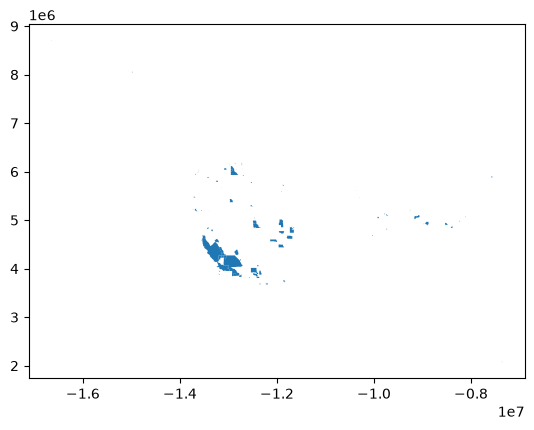

In [294]:
fig, ax = plt.subplots()
pm.plot(ax=ax)

### Intersecting PM and ozone

In [272]:
# Loading in the ozone dataset
ozone = gpd.read_file("data/smog_analysis/ozone_8hr.geojson")

In [295]:
pm.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [274]:
# Setting the crs
ozone = ozone.to_crs(epsg=3857)

In [296]:
overlap = gpd.sjoin(pm, ozone, predicate = "intersects")
overlap.head()

,AREA_NAME_1,Status,Status_120,Id,NAME,COMPOSID_1,AREA_NAME_2,COMPOSID_2,geometry,index_right,composite_,AREA_NAME,COMPOSID
1,"Imperial County, CA",NaN,Nonattainment,0.0,None,PM-2.5.2012.Imperial_Co,Imperial County; Imperial Valley planning area...,PM-10.1990.Imperial_Co,"POLYGON ((-12880779.17 3905256.819, -12880701....",21,Ozone_8-hr.2015.Imperial_Co.CA,"Imperial County, CA",Ozone_8-hr.2015.Imperial_Co
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",41,Ozone_8-hr.2015.Coachella_Valley.CA,"Riverside County (Coachella Valley), CA",Ozone_8-hr.2015.Coachella_Valley
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",25,Ozone_8-hr.2015.LA-South_Coast.CA,"Los Angeles-South Coast Air Basin, CA",Ozone_8-hr.2015.LA-South_Coast
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",29,Ozone_8-hr.2015.Morongo.CA,"Morongo Band of Mission Indians, CA",Ozone_8-hr.2015.Morongo
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",23,Ozone_8-hr.2015.LA-Desert.CA,Los Angeles-San Bernardino Counties (West Moja...,Ozone_8-hr.2015.LA-Desert


Text(0.5, 1.0, 'Areas in nonattainment for Ozone and PM')

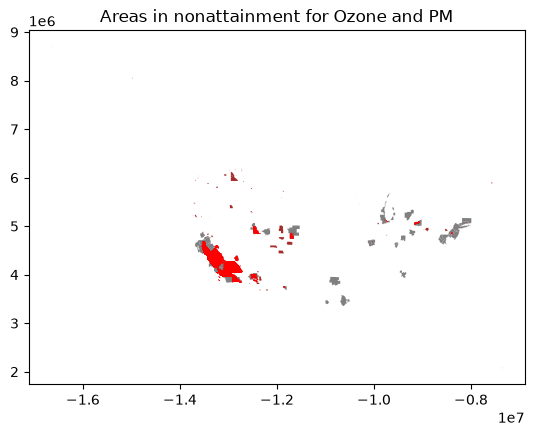

In [479]:
fig, ax = plt.subplots()
ozone.plot(ax=ax, color="gray")
pm.plot(ax=ax, color="brown")
overlap.plot(ax=ax, color="red")
plt.title("Areas in nonattainment for Ozone and PM")

### Analysis 
Adding a column for the area of overlap

In [298]:
overlap['Area (m)'] = overlap.area
overlap.head()

,AREA_NAME_1,Status,Status_120,Id,NAME,COMPOSID_1,AREA_NAME_2,COMPOSID_2,geometry,index_right,composite_,AREA_NAME,COMPOSID,Area (m)
1,"Imperial County, CA",NaN,Nonattainment,0.0,None,PM-2.5.2012.Imperial_Co,Imperial County; Imperial Valley planning area...,PM-10.1990.Imperial_Co,"POLYGON ((-12880779.17 3905256.819, -12880701....",21,Ozone_8-hr.2015.Imperial_Co.CA,"Imperial County, CA",Ozone_8-hr.2015.Imperial_Co,2.541897e+09
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",41,Ozone_8-hr.2015.Coachella_Valley.CA,"Riverside County (Coachella Valley), CA",Ozone_8-hr.2015.Coachella_Valley,7.839179e+08
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",25,Ozone_8-hr.2015.LA-South_Coast.CA,"Los Angeles-South Coast Air Basin, CA",Ozone_8-hr.2015.LA-South_Coast,7.839179e+08
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",29,Ozone_8-hr.2015.Morongo.CA,"Morongo Band of Mission Indians, CA",Ozone_8-hr.2015.Morongo,7.839179e+08
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",23,Ozone_8-hr.2015.LA-Desert.CA,Los Angeles-San Bernardino Counties (West Moja...,Ozone_8-hr.2015.LA-Desert,7.839179e+08


In [303]:
# Testing how to access area names
overlap.iloc[0]['AREA_NAME_2']

'Imperial County; Imperial Valley planning area, CA'

In [307]:
# Testing string subsetting 
str = "Example"
str[-2:]

'le'

In [325]:
overlap.index = range(len(overlap))
overlap.head()

,AREA_NAME_1,Status,Status_120,Id,NAME,COMPOSID_1,AREA_NAME_2,COMPOSID_2,geometry,index_right,composite_,AREA_NAME,COMPOSID,Area (m),State
0,"Imperial County, CA",NaN,Nonattainment,0.0,None,PM-2.5.2012.Imperial_Co,Imperial County; Imperial Valley planning area...,PM-10.1990.Imperial_Co,"POLYGON ((-12880779.17 3905256.819, -12880701....",21,Ozone_8-hr.2015.Imperial_Co.CA,"Imperial County, CA",Ozone_8-hr.2015.Imperial_Co,2.541897e+09,0
1,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",41,Ozone_8-hr.2015.Coachella_Valley.CA,"Riverside County (Coachella Valley), CA",Ozone_8-hr.2015.Coachella_Valley,7.839179e+08,1
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",25,Ozone_8-hr.2015.LA-South_Coast.CA,"Los Angeles-South Coast Air Basin, CA",Ozone_8-hr.2015.LA-South_Coast,7.839179e+08,2
3,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",29,Ozone_8-hr.2015.Morongo.CA,"Morongo Band of Mission Indians, CA",Ozone_8-hr.2015.Morongo,7.839179e+08,3
4,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",23,Ozone_8-hr.2015.LA-Desert.CA,Los Angeles-San Bernardino Counties (West Moja...,Ozone_8-hr.2015.LA-Desert,7.839179e+08,4


In [ ]:
# Add a new column with the name for each area (becuase some have name from dataframe 1, some dataframe 2, some from both)
# Create a state column for last two character in the string 

# Creating dummy values for new column 
# overlap['State'] = range(len(overlap))
overlap['State'] = pd.Series(dtype='str')

for i in range(len(overlap)):
    # Value in the cell
    value = overlap.loc[i,'AREA_NAME']
    state = value[-2:]
    overlap.loc[i,'State'] = state

overlap.head()

,AREA_NAME_1,Status,Status_120,Id,NAME,COMPOSID_1,AREA_NAME_2,COMPOSID_2,geometry,index_right,composite_,AREA_NAME,COMPOSID,Area (m),State
0,"Imperial County, CA",NaN,Nonattainment,0.0,None,PM-2.5.2012.Imperial_Co,Imperial County; Imperial Valley planning area...,PM-10.1990.Imperial_Co,"POLYGON ((-12880779.17 3905256.819, -12880701....",21,Ozone_8-hr.2015.Imperial_Co.CA,"Imperial County, CA",Ozone_8-hr.2015.Imperial_Co,2.541897e+09,CA
1,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",41,Ozone_8-hr.2015.Coachella_Valley.CA,"Riverside County (Coachella Valley), CA",Ozone_8-hr.2015.Coachella_Valley,7.839179e+08,CA
2,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",25,Ozone_8-hr.2015.LA-South_Coast.CA,"Los Angeles-South Coast Air Basin, CA",Ozone_8-hr.2015.LA-South_Coast,7.839179e+08,CA
3,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",29,Ozone_8-hr.2015.Morongo.CA,"Morongo Band of Mission Indians, CA",Ozone_8-hr.2015.Morongo,7.839179e+08,CA
4,"Los Angeles-South Coast Air Basin, CA",Both,Nonattainment,0.0,None,PM-2.5.2012.LA-South_Coast,Riverside County; Coachella Valley planning ar...,PM-10.1990.Coachella_Valley,"MULTIPOLYGON (((-12993146.845 4033344.265, -12...",23,Ozone_8-hr.2015.LA-Desert.CA,Los Angeles-San Bernardino Counties (West Moja...,Ozone_8-hr.2015.LA-Desert,7.839179e+08,CA


Text(0, 0.5, 'Area (m)')

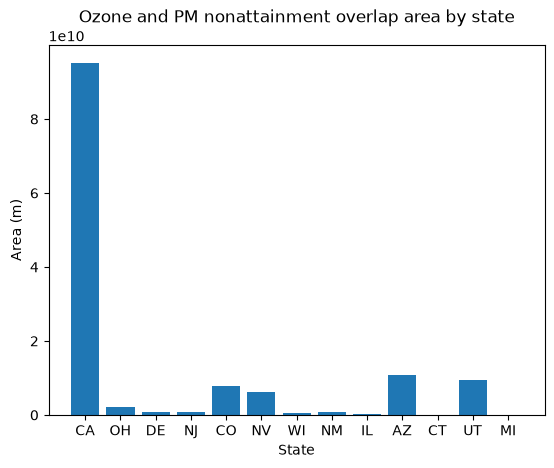

In [484]:
plt.bar(x=overlap['State'], height=overlap['Area (m)'])
plt.title("Ozone and PM nonattainment overlap area by state")
plt.xlabel("State")
plt.ylabel("Area (m)")

## Analysis 3: Puerto Rico solar 
In this analysis, I will find areas with high solar potential and that need community improvement. The results could be used by the government or nonprofits to subsidize solar panel installation in vulnerable areas. 

In [450]:
# Loading in data 
solar_potential = pd.read_csv("data/puerto_rico_solar/pr_lmi_pvr_potential.csv")
pr_tracts = gpd.read_file("data/puerto_rico_solar/pr_tracts_2000.geojson")
special_communities = gpd.read_file("data/puerto_rico_solar/special_communities.geojson")

According to the website the 'special_communities' dataframe was found on: "This data layer was created by the Geographic Information System Division of the Puerto Rico Department of Housing to locate "Special Communities" (Comunidades Especiales) that receive funding for the construction or rehabilitation of public housing—as well as for other projects—within these communities."
https://gis.pr.gov/descargaGeodatos/Delimitaciones/Pages/Comunidades.aspx 

In [451]:
# Setting projections
# Projection for Puerto Rico https://spatialreference.org/ref/epsg/4437/ 
# Projection is in meters 
pr_tracts = pr_tracts.to_crs(epsg=4437)
special_communities = special_communities.to_crs(epsg=4437)

### Filtering the solar data 

In [452]:
solar_potential.head()

,Unnamed: 0,geoid,very_low_mf_own_hh,very_low_mf_rent_hh,very_low_sf_own_hh,very_low_sf_rent_hh,low_mf_own_hh,low_mf_rent_hh,low_sf_own_hh,low_sf_rent_hh,...,mod_sf_own_mwh,mod_sf_rent_mwh,mid_mf_own_mwh,mid_mf_rent_mwh,mid_sf_own_mwh,mid_sf_rent_mwh,high_mf_own_mwh,high_mf_rent_mwh,high_sf_own_mwh,high_sf_rent_mwh
0,0,72127980108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000,0.0000,0.000000,0.0000,0.000,0.00000,0.0000,0.0000,0.00,0.00000
1,1,72127010500,34.790789,391.603163,8.210174,10.331161,2.826217,87.971574,0.425298,2.981233,...,118.951,79.8902,625.221300,150.7717,193.533,5.20579,9267.3500,766.6820,1133.43,253.41700
2,2,72053150102,6.084392,15.623264,56.690059,13.636997,4.429540,15.669173,68.504501,17.762265,...,3074.560,956.5980,323.203000,590.0460,11097.800,1824.10000,80.5473,138.8310,3049.55,414.21300
3,3,72127002800,35.861823,113.408463,110.713754,39.992232,32.015167,73.902763,68.046738,32.904948,...,1771.310,390.2770,275.293800,659.6718,1596.290,5.57931,252.4512,578.7766,2033.40,3.18818
4,4,72135510601,9.680703,11.029639,125.390769,62.779777,8.758619,2.225133,79.288509,10.024369,...,1833.400,260.5020,227.193201,107.3310,1321.220,177.97800,864.0250,234.3530,17654.40,769.94200


Metadata about column names found in data/puerto_rico_solar/data-documentation[1].docx \
I want information about the number of households that are suitable for solar, I will normalize this data with the number of households by taking a percentage suitable for solar divided by the total. \
I will use household that are very low income or low income and just those that own their house, so there are no problems with modifications to rented housing.

In [453]:
solar_potential.columns

Index(['Unnamed: 0', 'geoid', 'very_low_mf_own_hh', 'very_low_mf_rent_hh',
       'very_low_sf_own_hh', 'very_low_sf_rent_hh', 'low_mf_own_hh',
       'low_mf_rent_hh', 'low_sf_own_hh', 'low_sf_rent_hh',
       ...
       'mod_sf_own_mwh', 'mod_sf_rent_mwh', 'mid_mf_own_mwh',
       'mid_mf_rent_mwh', 'mid_sf_own_mwh', 'mid_sf_rent_mwh',
       'high_mf_own_mwh', 'high_mf_rent_mwh', 'high_sf_own_mwh',
       'high_sf_rent_mwh'],
      dtype='str', length=142)

In [454]:
# mf is multi-family, sf is single family
# Also copying to make a new dataframe here for filtering. 
potential_filtered = solar_potential[['geoid', 
                                      'very_low_mf_own_hh', 
                                      'very_low_sf_own_hh', 
                                      'low_mf_own_hh', 
                                      'low_sf_own_hh', 
                                      'very_low_mf_own_bldg_cnt', 
                                      'very_low_sf_own_bldg_cnt', 
                                      'low_mf_own_bldg_cnt', 
                                      'low_sf_own_bldg_cnt']].copy()
potential_filtered.head()

,geoid,very_low_mf_own_hh,very_low_sf_own_hh,low_mf_own_hh,low_sf_own_hh,very_low_mf_own_bldg_cnt,very_low_sf_own_bldg_cnt,low_mf_own_bldg_cnt,low_sf_own_bldg_cnt
0,72127980108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,72127010500,34.790789,8.210174,2.826217,0.425298,1.041951,6.350922,0.291451,0.328831
2,72053150102,6.084392,56.690059,4.429540,68.504501,3.472828,81.476450,2.528758,98.461987
3,72127002800,35.861823,110.713754,32.015167,68.046738,19.832463,203.164137,15.929256,124.901994
4,72135510601,9.680703,125.390769,8.758619,79.288509,3.216827,112.017086,2.933686,70.856446


In [455]:
# Aggregating total households for each category and suitable households for each category. 
potential_filtered['total_households'] = potential_filtered['very_low_mf_own_hh'] + potential_filtered['very_low_sf_own_hh'] + potential_filtered['low_mf_own_hh'] + potential_filtered['low_sf_own_hh']
potential_filtered['total_suitable'] = potential_filtered['very_low_mf_own_bldg_cnt'] + potential_filtered['very_low_sf_own_bldg_cnt'] + potential_filtered[ 'low_mf_own_bldg_cnt'] + potential_filtered['low_sf_own_bldg_cnt']
potential_filtered['suitable_percentage'] = potential_filtered['total_suitable'] / potential_filtered['total_households'] * 100
potential_filtered.head()

,geoid,very_low_mf_own_hh,very_low_sf_own_hh,low_mf_own_hh,low_sf_own_hh,very_low_mf_own_bldg_cnt,very_low_sf_own_bldg_cnt,low_mf_own_bldg_cnt,low_sf_own_bldg_cnt,total_households,total_suitable,suitable_percentage
0,72127980108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,72127010500,34.790789,8.210174,2.826217,0.425298,1.041951,6.350922,0.291451,0.328831,46.252479,8.013155,17.324813
2,72053150102,6.084392,56.690059,4.429540,68.504501,3.472828,81.476450,2.528758,98.461987,135.708493,185.940023,137.014287
3,72127002800,35.861823,110.713754,32.015167,68.046738,19.832463,203.164137,15.929256,124.901994,246.637482,363.827851,147.515231
4,72135510601,9.680703,125.390769,8.758619,79.288509,3.216827,112.017086,2.933686,70.856446,223.118599,189.024044,84.719089


### Joining attribute data to census tracts

In [456]:
pr_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,72,119,992700,72119992700,9927,Census Tract 9927,G5020,S,0,68606856,+18.4396699,-065.7704573,"MULTIPOLYGON (((264081.352 265907.033, 264132...."
1,72,119,130702,72119130702,1307.02,Census Tract 1307.02,G5020,S,10909676,9644,+18.3548286,-065.8449461,"MULTIPOLYGON (((259755.76 255906.963, 259772.5..."
2,72,119,130500,72119130500,1305,Census Tract 1305,G5020,S,1209818,0,+18.3758737,-065.8455726,"MULTIPOLYGON (((261392.694 259893.522, 261398...."
3,72,119,130300,72119130300,1303,Census Tract 1303,G5020,S,8609804,110315,+18.3958577,-065.8346708,"MULTIPOLYGON (((261368.135 263005.135, 261643...."
4,72,087,110200,72087110200,1102,Census Tract 1102,G5020,S,1068915,791590,+18.4307274,-065.8463672,"MULTIPOLYGON (((261706.021 267120.066, 262550...."


I got an error the first time I tried to do an attribute join because one geoid field was a string, and the other was an int. 

In [457]:
pr_tracts.dtypes

STATEFP          str
COUNTYFP         str
TRACTCE          str
GEOID            str
NAME             str
NAMELSAD         str
MTFCC            str
FUNCSTAT         str
ALAND          int32
AWATER         int32
INTPTLAT         str
INTPTLON         str
geometry    geometry
dtype: object

In [458]:
potential_filtered.dtypes

geoid                         int64
very_low_mf_own_hh          float64
very_low_sf_own_hh          float64
low_mf_own_hh               float64
low_sf_own_hh               float64
very_low_mf_own_bldg_cnt    float64
very_low_sf_own_bldg_cnt    float64
low_mf_own_bldg_cnt         float64
low_sf_own_bldg_cnt         float64
total_households            float64
total_suitable              float64
suitable_percentage         float64
dtype: object

In [459]:
pr_tracts.rename(columns={'GEOID': 'geoid'}, inplace=True)
pr_tracts.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'geoid', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [460]:
pr_tracts = pr_tracts.astype({'geoid':int})
pr_tracts.dtypes

STATEFP          str
COUNTYFP         str
TRACTCE          str
geoid          int64
NAME             str
NAMELSAD         str
MTFCC            str
FUNCSTAT         str
ALAND          int32
AWATER         int32
INTPTLAT         str
INTPTLON         str
geometry    geometry
dtype: object

In [461]:
solar_tracts = pr_tracts.merge(potential_filtered, on='geoid')
solar_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,geoid,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,very_low_sf_own_hh,low_mf_own_hh,low_sf_own_hh,very_low_mf_own_bldg_cnt,very_low_sf_own_bldg_cnt,low_mf_own_bldg_cnt,low_sf_own_bldg_cnt,total_households,total_suitable,suitable_percentage
0,72,119,992700,72119992700,9927,Census Tract 9927,G5020,S,0,68606856,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,72,119,130702,72119130702,1307.02,Census Tract 1307.02,G5020,S,10909676,9644,...,174.152383,18.711580,157.342245,11.515444,133.587594,6.949077,120.739909,381.159726,272.792023,71.568952
2,72,119,130500,72119130500,1305,Census Tract 1305,G5020,S,1209818,0,...,182.464093,5.871611,104.410097,9.535395,10.124785,3.362478,1.731048,308.623085,24.753706,8.020692
3,72,119,130300,72119130300,1303,Census Tract 1303,G5020,S,8609804,110315,...,88.416576,15.350892,134.701986,10.182560,12.728154,11.399019,0.368727,256.743217,34.678460,13.507060
4,72,087,110200,72087110200,1102,Census Tract 1102,G5020,S,1068915,791590,...,160.673874,9.760171,40.591117,15.044492,208.220223,5.226855,52.636463,239.126494,281.128033,117.564569


### Clipping solar data to community improvement polygons

In [462]:
target_areas = gpd.clip(solar_tracts, special_communities)
target_areas.head()

,STATEFP,COUNTYFP,TRACTCE,geoid,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,very_low_sf_own_hh,low_mf_own_hh,low_sf_own_hh,very_low_mf_own_bldg_cnt,very_low_sf_own_bldg_cnt,low_mf_own_bldg_cnt,low_sf_own_bldg_cnt,total_households,total_suitable,suitable_percentage
524,72,113,071601,72113071601,716.01,Census Tract 716.01,G5020,S,1299246,2422290,...,81.001723,13.867487,53.617619,10.531608,106.880660,5.884088,70.753495,180.294392,194.049852,107.629445
584,72,113,072101,72113072101,721.01,Census Tract 721.01,G5020,S,3400690,1041532,...,75.072330,3.557259,63.843855,4.829072,107.807043,1.854099,91.705991,158.064839,206.196206,130.450395
142,72,113,072300,72113072300,723,Census Tract 723,G5020,S,29485689,26190987,...,49.569848,4.512275,74.266040,1.672992,49.769871,2.002258,74.521443,132.119351,127.966565,96.856792
302,72,133,953600,72133953600,9536,Census Tract 9536,G5020,S,22913790,18678307,...,270.606069,14.176750,125.800541,17.069515,0.127265,6.816601,11.773810,446.112684,35.787192,8.022007
301,72,133,953800,72133953800,9538,Census Tract 9538,G5020,S,5799726,1937530,...,105.907581,12.201876,111.063479,9.602649,165.034847,8.549455,173.043700,242.878693,356.230651,146.670194


In [463]:
over_100 = target_areas[target_areas['suitable_percentage'] > 100]
over_100['suitable_percentage'].count()

np.int64(316)

### Take 2

For some reason, many of the percentages are over 100. Perhaps due to fields that have 0 to indicate null, or because of the way the data was categorized. Below, I re-try with just one category. I am also changing it to use renters and multi-family households, because I noticed the special communities are for public housing projects. I theorize that these areas may have more renters. From scanning the Excel sheet this seems to be true. If the housing is government owned, then installing solar panels on rented homes should be less of an issue. 

In [464]:
public_housing = solar_potential[['geoid', 'very_low_mf_rent_hh', 'very_low_mf_rent_bldg_cnt']].copy()
public_housing.head()

,geoid,very_low_mf_rent_hh,very_low_mf_rent_bldg_cnt
0,72127980108,0.000000,0.000000
1,72127010500,391.603163,8.735373
2,72053150102,15.623264,7.994884
3,72127002800,113.408463,58.169792
4,72135510601,11.029639,3.731576


In [ ]:
# Checking to make sure the same issue isn't happening again
over_100 = public_housing[public_housing['suitable_percentage'] > 100]
over_100['suitable_percentage'].count()

np.int64(0)

In [468]:
public_housing['suitable_percentage'] = public_housing['very_low_mf_rent_bldg_cnt'] / public_housing['very_low_mf_rent_hh'] * 100
public_housing.head()

,geoid,very_low_mf_rent_hh,very_low_mf_rent_bldg_cnt,suitable_percentage
0,72127980108,0.000000,0.000000,NaN
1,72127010500,391.603163,8.735373,2.230670
2,72053150102,15.623264,7.994884,51.172947
3,72127002800,113.408463,58.169792,51.292285
4,72135510601,11.029639,3.731576,33.832256


### Redoing the attribute join and clip

In [ ]:
# I modified the original pr_tracts dataframe above to fix the geoid data type issue, so I don't need to repeat that. 
suitable_tracts = pr_tracts.merge(public_housing, on="geoid")
suitable_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,geoid,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,very_low_mf_rent_hh,very_low_mf_rent_bldg_cnt,suitable_percentage
0,72,119,992700,72119992700,9927,Census Tract 9927,G5020,S,0,68606856,+18.4396699,-065.7704573,"MULTIPOLYGON (((264081.352 265907.033, 264132....",0.000000,0.000000,NaN
1,72,119,130702,72119130702,1307.02,Census Tract 1307.02,G5020,S,10909676,9644,+18.3548286,-065.8449461,"MULTIPOLYGON (((259755.76 255906.963, 259772.5...",16.252040,4.663004,28.691808
2,72,119,130500,72119130500,1305,Census Tract 1305,G5020,S,1209818,0,+18.3758737,-065.8455726,"MULTIPOLYGON (((261392.694 259893.522, 261398....",86.245386,12.860100,14.911058
3,72,119,130300,72119130300,1303,Census Tract 1303,G5020,S,8609804,110315,+18.3958577,-065.8346708,"MULTIPOLYGON (((261368.135 263005.135, 261643....",2.321724,1.734646,74.713695
4,72,087,110200,72087110200,1102,Census Tract 1102,G5020,S,1068915,791590,+18.4307274,-065.8463672,"MULTIPOLYGON (((261706.021 267120.066, 262550....",27.434490,14.700033,53.582309


In [ ]:
target_areas = gpd.clip(suitable_tracts, special_communities)

### Plotting 

Chloropleth map

Text(0.5, 1.0, 'Percentage of solar suitable very low income buildings')

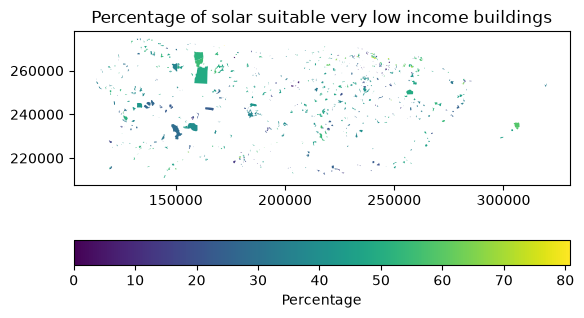

In [ ]:
fig, ax = plt.subplots()
target_areas.plot(ax=ax, 
                  column='suitable_percentage', 
                  legend=True,
                  legend_kwds={"label": "Percentage", "orientation": "horizontal"})
plt.title("Percentage of solar suitable very low income buildings")

Displaying just the areas over 50%

Text(0.5, 1.0, 'Percentage of solar suitable very low income buildings')

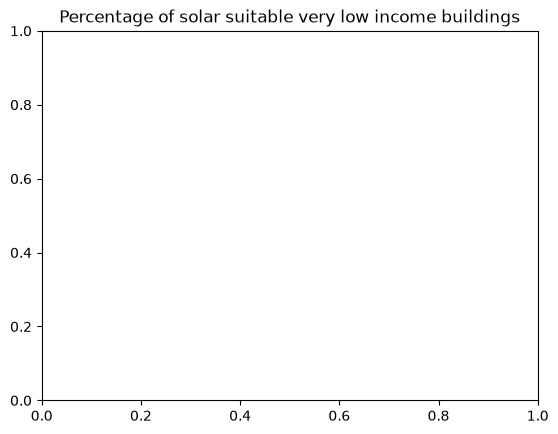

In [ ]:
areas_over50 = target_areas[target_areas['suitable_percentage'] > 50]
areas_over50.head()
# fig, ax = plt.subplots()
# areas_over50.plot(ax=ax, 
#                   column='suitable_percentage', 
#                   legend=True,
#                   legend_kwds={"label": "Percentage", "orientation": "horizontal"})
# plt.title("Percentage of solar suitable very low income buildings")